import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect("photonic_benchmark.db")

# 1. Übersicht
df = con.execute("SELECT * FROM experiments").df()
print(df.shape)
print(df.describe())

# 2. Wichtige Visualisierungen
sns.boxplot(data=df, x='matrix_size', y='mae')
plt.title('MAE nach Matrix-Größe')
plt.show()

sns.scatterplot(data=df, x='noise_level', y='effective_bits', hue='matrix_size')
plt.title('Effective Bits vs Noise Level')
plt.show()

In [1]:
# Zelle 1: Imports & Verbindung zur Datenbank
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✅ Bibliotheken geladen")

# Verbindung zur DB
con = duckdb.connect("photonic_benchmark.db")
print("✅ Mit Datenbank verbunden")

✅ Bibliotheken geladen
✅ Mit Datenbank verbunden


In [2]:
# Zelle 2: Daten laden + erste Übersicht
df = con.execute("""
    SELECT * FROM experiments 
    ORDER BY matrix_size, noise_level
""").df()

print(f"Datensatz geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten")
print("\nSpalten:")
print(df.columns.tolist())

display(df.head())
display(df.describe())

Datensatz geladen: 210 Zeilen, 11 Spalten

Spalten:
['sample_id', 'matrix_size', 'noise_level', 'drift_factor', 'crosstalk_factor', 'bit_precision', 'mae', 'rmse', 'snr_db', 'effective_bits', 'timestamp']


,sample_id,matrix_size,noise_level,drift_factor,crosstalk_factor,bit_precision,mae,rmse,snr_db,effective_bits,timestamp
0,0,32,0.005,0.002,0.003,8,0.005220,0.007651,54.056958,9.530276,2026-07-04 10:46:27.275935
1,1,32,0.005,0.002,0.003,8,0.004987,0.007189,56.710352,9.946949,2026-07-04 10:46:27.275949
2,2,32,0.005,0.002,0.003,8,0.005107,0.007484,55.805182,9.820520,2026-07-04 10:46:27.275953
3,3,32,0.005,0.002,0.003,8,0.005847,0.008449,56.858187,9.974978,2026-07-04 10:46:27.275958
4,4,32,0.005,0.002,0.003,8,0.005162,0.007565,56.535140,9.941730,2026-07-04 10:46:27.275963


,sample_id,matrix_size,noise_level,drift_factor,crosstalk_factor,bit_precision,mae,rmse,snr_db,effective_bits,timestamp
count,210.000000,210.000000,210.000000,210.000000,210.000,210.0,210.000000,210.000000,210.000000,210.000000,210
mean,35.928571,67.047619,0.013571,0.004571,0.003,8.0,0.020520,0.031976,50.451521,8.991497,2026-07-04 10:46:27.276393472
min,0.000000,32.000000,0.005000,0.002000,0.003,8.0,0.004685,0.006797,43.534023,7.882262,2026-07-04 10:46:27.275935
25%,17.000000,32.000000,0.005000,0.002000,0.003,8.0,0.005312,0.007810,47.076136,8.464714,2026-07-04 10:46:27.276183296
50%,34.500000,64.000000,0.015000,0.005000,0.003,8.0,0.019649,0.030607,48.485226,8.690587,2026-07-04 10:46:27.276391936
75%,53.000000,64.000000,0.015000,0.005000,0.003,8.0,0.020583,0.032378,55.921069,9.867007,2026-07-04 10:46:27.276621056
max,79.000000,128.000000,0.025000,0.008000,0.003,8.0,0.047091,0.073990,58.614582,10.295938,2026-07-04 10:46:27.276823
std,22.339692,36.912513,0.007756,0.002327,0.000,0.0,0.015715,0.024904,5.005132,0.787871,NaN


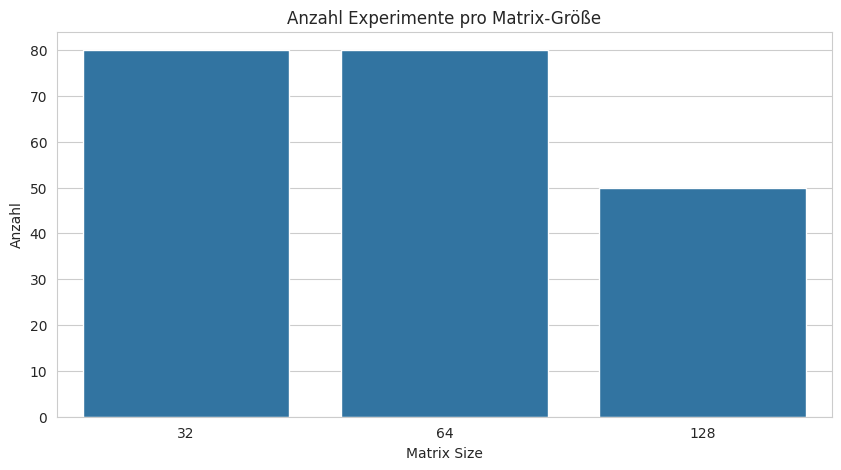

In [3]:
# Zelle 3: Verteilung der Matrix-Größen
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='matrix_size')
plt.title('Anzahl Experimente pro Matrix-Größe')
plt.xlabel('Matrix Size')
plt.ylabel('Anzahl')
plt.show()

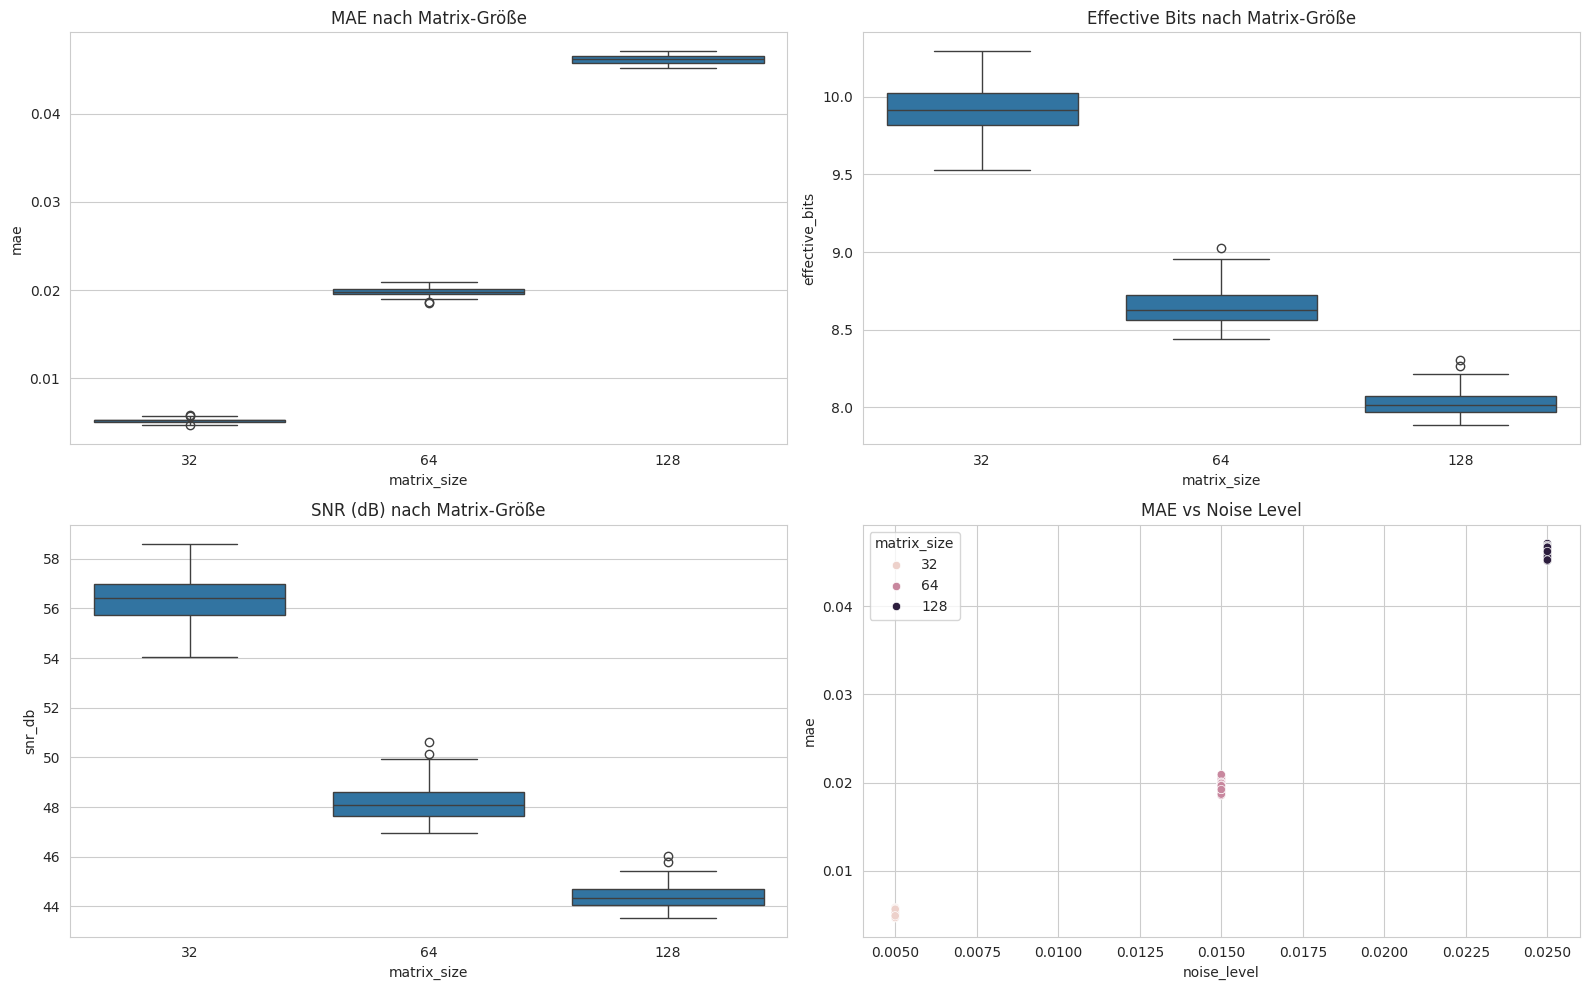

In [4]:
# Zelle 4: Performance-Metrik nach Matrix-Größe
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=df, x='matrix_size', y='mae', ax=axes[0,0])
axes[0,0].set_title('MAE nach Matrix-Größe')

sns.boxplot(data=df, x='matrix_size', y='effective_bits', ax=axes[0,1])
axes[0,1].set_title('Effective Bits nach Matrix-Größe')

sns.boxplot(data=df, x='matrix_size', y='snr_db', ax=axes[1,0])
axes[1,0].set_title('SNR (dB) nach Matrix-Größe')

sns.scatterplot(data=df, x='noise_level', y='mae', hue='matrix_size', ax=axes[1,1])
axes[1,1].set_title('MAE vs Noise Level')

plt.tight_layout()
plt.show()

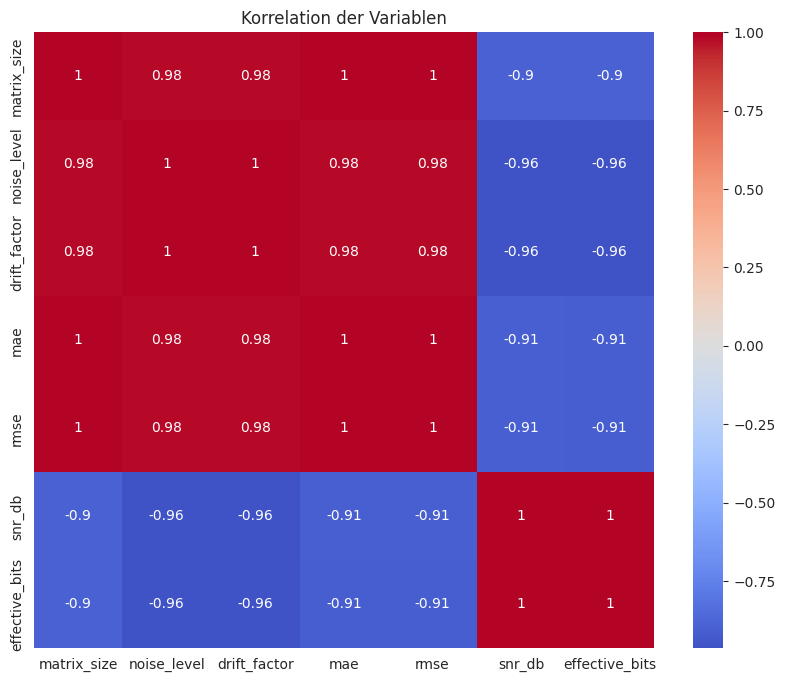

In [5]:
# Zelle 5: Korrelationen
corr = df[['matrix_size', 'noise_level', 'drift_factor', 'mae', 'rmse', 
           'snr_db', 'effective_bits']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Korrelation der Variablen')
plt.show()

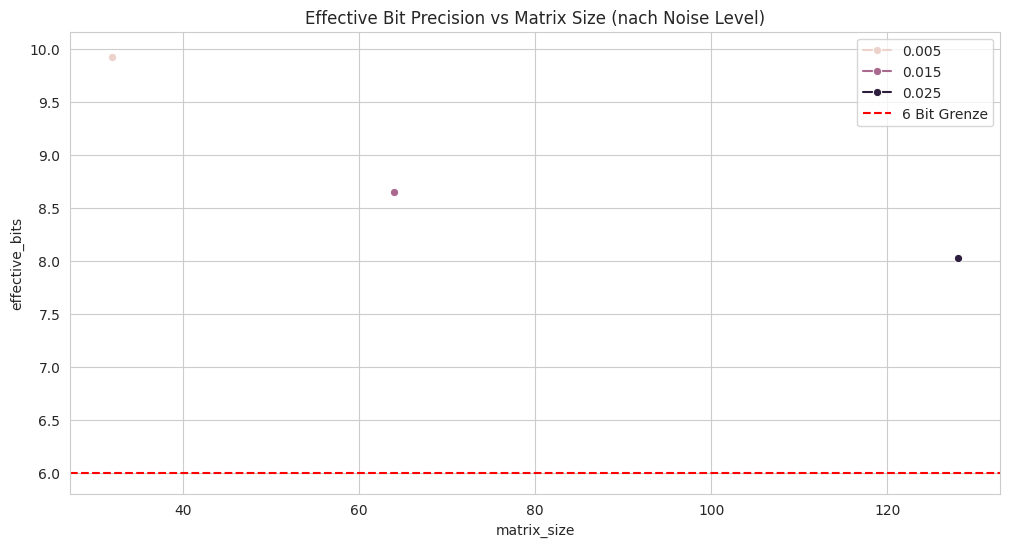

In [6]:
# Zelle 6: Research-Question-Visualisierungen

# RQ2: Ab welcher Größe wird es kritisch?
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='matrix_size', y='effective_bits', 
             hue='noise_level', marker='o')
plt.title('Effective Bit Precision vs Matrix Size (nach Noise Level)')
plt.axhline(y=6, color='r', linestyle='--', label='6 Bit Grenze')
plt.legend()
plt.show()

In [7]:
# Zelle 7: Zusammenfassung & nächste Schritte
print("=== EDA-Zusammenfassung ===")
print(f"Matrix-Größen: {sorted(df['matrix_size'].unique())}")
print(f"Max MAE: {df['mae'].max():.5f}")
print(f"Min Effective Bits: {df['effective_bits'].min():.2f}")

print("\nNächste mögliche Schritte:")
print("- Vergleich mit realen Paper-Daten (Notebook 1 erweitern)")
print("- Statistische Tests (z.B. Korrelation Signifikanz)")
print("- Modellierung von Prediction (Regression)")
print("- Interaktive Plots mit Plotly")

=== EDA-Zusammenfassung ===
Matrix-Größen: [np.int64(32), np.int64(64), np.int64(128)]
Max MAE: 0.04709
Min Effective Bits: 7.88

Nächste mögliche Schritte:
- Vergleich mit realen Paper-Daten (Notebook 1 erweitern)
- Statistische Tests (z.B. Korrelation Signifikanz)
- Modellierung von Prediction (Regression)
- Interaktive Plots mit Plotly


In [8]:
con.close()